In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
auto = pd.read_csv("../../Auto.data", sep='\s+')
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
394,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [64]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    float64
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.0+ KB


In [65]:
auto.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


(a) Quantative predictors are: mpg, displacement, weight, acceleration, horsepower
    Qualitative predictors are: year, cylinders, origin, name

(b) Range of qualititative predictors can be found in the above cell.

(c) Same as be can be found in the cell with auto.describe()

In [66]:
# Above horsepower is not showing, on further inspection I found that it is in object data type, also when I looked the data in text editor found that there are some missing values there and they are represeted as '?' so correcting it by replacing with NA
auto["horsepower"] = auto["horsepower"].replace('?', np.nan)

In [67]:
auto = auto.astype({'horsepower':'float64'})
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

(d)

In [68]:
required = list(range(10)) + list(range(86, len(auto)))
auto1 = auto.iloc[required]
auto1

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [58]:
auto1.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,321.000000,321.000000,321.000000,317.000000,321.000000,321.000000,321.000000,321.000000
mean,24.444860,5.370717,187.174455,101.003155,2933.183801,15.709034,77.143302,1.598131
std,7.899928,1.653486,99.864568,36.003208,809.638650,2.706441,3.128202,0.816163
min,11.000000,3.000000,68.000000,46.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,100.000000,75.000000,2215.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,145.000000,90.000000,2795.000000,15.500000,77.000000,1.000000
75%,30.700000,6.000000,250.000000,115.000000,3504.000000,17.300000,80.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,24.800000,82.000000,3.000000


(e)

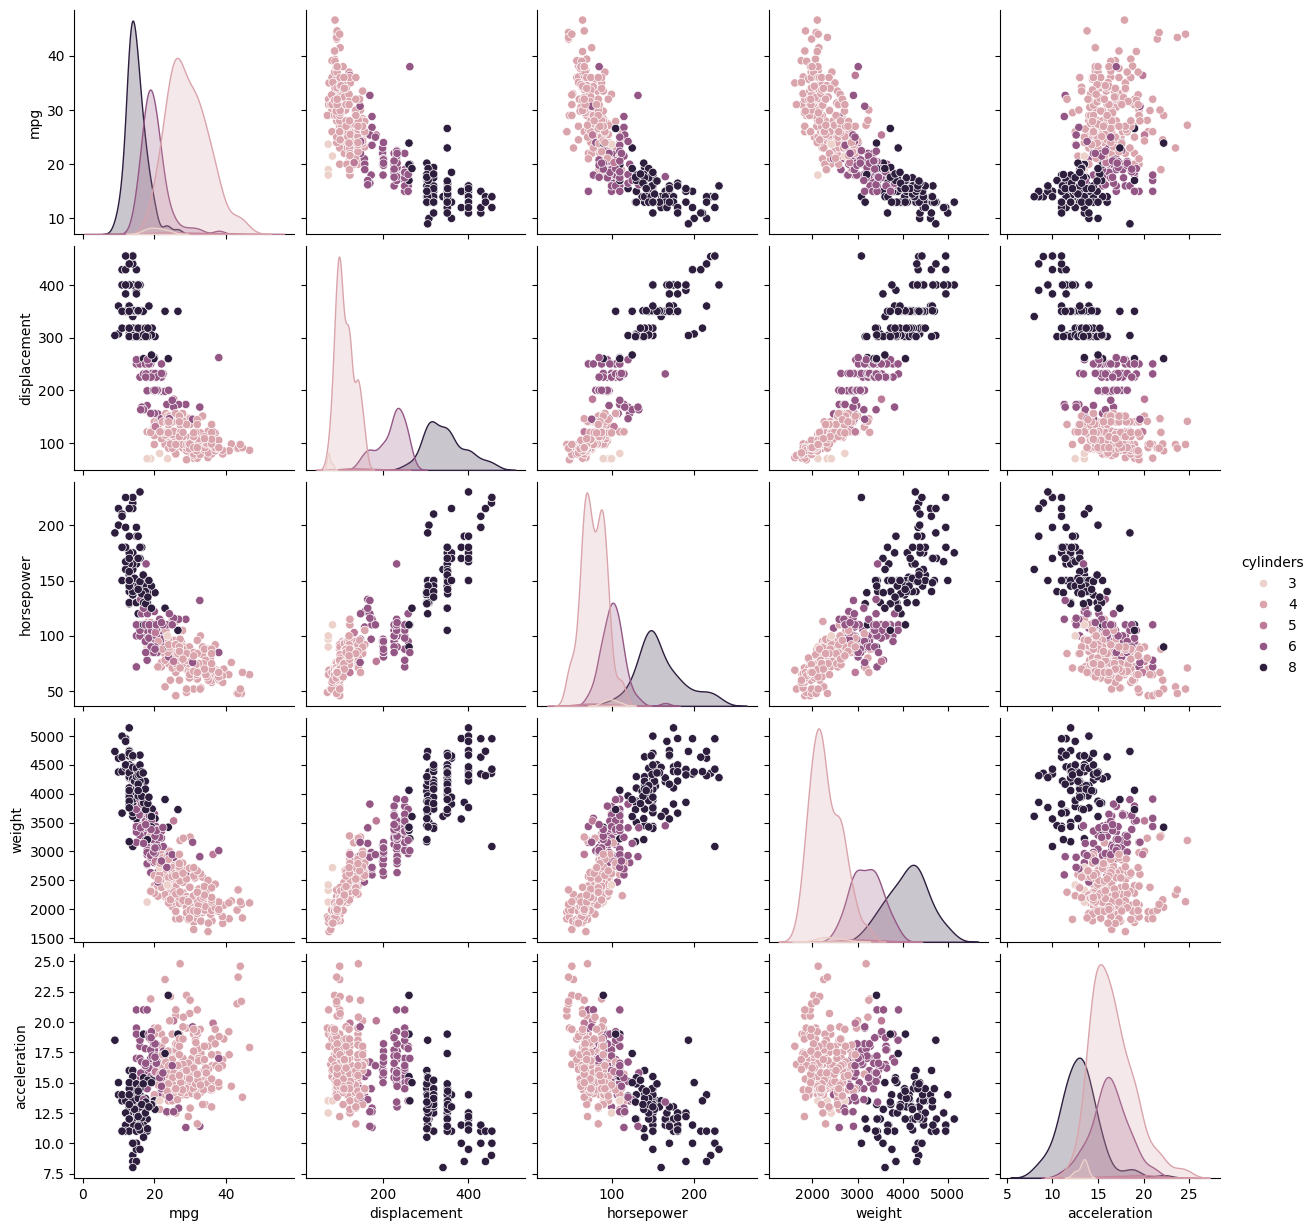

In [77]:
sns.pairplot(auto, vars=["mpg", "displacement", "horsepower", "weight", "acceleration"], diag_kind="kde", hue='cylinders')

(f)

Yes, the plot suggest that the other variable will be useful in calculating the mileage. 
Exaplanation: 
We can clearly see an association between mpg and displacement. Its something like as the displacement is decreasing the mpg is increasing.
Similar kind of association is there with weight and horsepower.
Though there is a weak kind of correlation between the acceleraion and the mpg.


In [1]:
pip show ISLP

Note: you may need to restart the kernel to use updated packages.
